# Solver configuration and optimization utilities.

This example shows how to configure the optimizer via `pln.prop_opt`,
track the objective history, and work with objectives.

In [1]:
import logging
import matplotlib.pyplot as plt

from pyRadPlan import (
    IonPlan,
    generate_stf,
    calc_dose_influence,
    fluence_optimization,
    load_tg119,
)

from pyRadPlan.optimization.objectives import SquaredDeviation, SquaredOverdosing, MeanDose
from pyRadPlan.optimization.solvers import get_available_solvers

logging.basicConfig(level=logging.INFO)

D:\Python\pyRadPlan\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
ct, cst = load_tg119()

## Configuring `pln.prop_opt`

`pln.prop_opt` is a dictionary that controls the optimization.
All keys are forwarded as attributes to the planning problem.

| Key        | Type        | Default        | Description                                   |
|------------|-------------|----------------|-----------------------------------------------|
| `solver`   | str or dict | `"ipopt"`      | `"scipy"` (L-BFGS-B) or `"ipopt"` (Interior Point), or a dict for full control (see below) |
| `display`  | bool        | solver default | Show solver iteration output                  |
| `max_iter` | int         | solver default | Maximum number of iterations                  |

`display` and `max_iter` are convenience shortcuts for the two solver settings that are
useful regardless of the solver. Set at top-level they take priority over the same keys
inside the `solver` dict; left unset, whatever the solver is configured with applies
(the value from the `solver` dict, or the solver's own default).

A solver named here explicitly must be available: naming one that is not registered raises,
rather than quietly substituting another and returning a plan optimized by something else.
IPOPT ships in the separate `ipyopt` package, which pyRadPlan does not depend on, so this
example picks it only when it is installed and falls back to SciPy otherwise.

In [3]:
solver_name = "ipopt" if "ipopt" in get_available_solvers() else "scipy"
print(f"Using the '{solver_name}' solver")

pln = IonPlan(radiation_mode="protons", machine="Generic")

pln.prop_opt = {
    "solver": solver_name,
    "display": True,  # set False to silence iteration output
    "max_iter": 200,
}

pln.prop_dose_calc = {"dose_grid": ct.grid}

stf = generate_stf(ct, cst, pln)
dij = calc_dose_influence(ct, cst, stf, pln)

Using the 'ipopt' solver


Beam:   0%|          | 0/1 [00:00<?, ?b/s]

Beam: 100%|██████████| 1/1 [00:01<00:00,  1.62s/b]

INFO:pyRadPlan.dose.engines._base:Dose influence matrix calculation using 'Hong Particle Pencil-Beam' Dose Engine...


INFO:pyRadPlan.dose.engines._base:Dose Grid has Dimensions (167,167,129) with resolution x=3.000000, y=3.000000, z=2.500000.


...

Ray: 100%|█████████▉| 315/316 [00:27<00:00, 13.35r/s]

Beam: 100%|██████████| 1/1 [00:29<00:00, 29.83s/b]

INFO:pyRadPlan.dose.engines._base_pencilbeam:Finalizing dose calculation...


INFO:pyRadPlan.dose.engines._base_pencilbeam:Done in 0.015595 seconds.


INFO:pyRadPlan.dose.engines._base:Dose influence matrix calculation done in 31.53 seconds.


## Available objectives

Objectives are assigned per VOI via `cst.vois[i].objectives`.
Each has a `priority` (weight) and objective-specific parameters.

| Objective             | Key parameters           | Use case                         |
|-----------------------|--------------------------|----------------------------------|
| `SquaredDeviation`    | `d_ref`                  | Target dose prescription         |
| `SquaredOverdosing`   | `d_max`                  | Upper dose limit (OAR/target)    |
| `SquaredUnderdosing`  | `d_min`                  | Lower dose limit (target)        |
| `MeanDose`            | `d_ref`                  | Mean dose objective              |
| `EUD`                 | `eud_ref`, `k`- exponent | Equivalent uniform dose          |
| `MinDVH`              | `d`, `v_min`             | DVH lower bound at volume %      |
| `MaxDVH`              | `d`, `v_max`             | DVH upper bound at volume %      |
| `DoseUniformity`      | *(none)*                 | Minimize dose variance           |

The `priority` parameter controls the relative weighting of the objectives.
Check `pyRadPlan.optimization.objectives` for more info

In [4]:
cst.vois[0].objectives = [SquaredOverdosing(priority=10.0, d_max=1.0)]  # OAR
cst.vois[1].objectives = [SquaredDeviation(priority=100.0, d_ref=3.0)]  # Target
cst.vois[2].objectives = [MeanDose(priority=1.0, d_ref=0.0)]  # Body

## Tracking optimization info

Pass an empty dict as ``opt_info`` to ``fluence_optimization``.
After the solve it will contain ``obj_history`` (objective values per
evaluation), ``num_iter`` (number of iterations), and ``result_info``
(solver-specific result details like convergence status).

In [5]:
opt_info = {}
fluence = fluence_optimization(ct, cst, stf, dij, pln, opt_info=opt_info)

INFO:pyRadPlan.optimization.problems._optiprob:Converting all objectives to use quantity: physical_dose


INFO:pyRadPlan.dij._dij:Converted Dij to namespace 'array_api_compat.cupy'


INFO:pyRadPlan.quantities._base:Optimization will use array backend: array_api_compat.cupy


INFO:pyRadPlan.util.keyboard_listener:Press 'q' or ESC to stop optimization early.


INFO:pyRadPlan.optimization.solvers._base_solvers:Starting optimization using Interior Point Optimizer


...

INFO:pyRadPlan.optimization.solvers._ipopt:ipopt: Total seconds in NLP function evaluations            =     10.994


INFO:pyRadPlan.optimization.solvers._ipopt:ipopt: EXIT: Maximum Number of Iterations Exceeded.


INFO:pyRadPlan.optimization.problems._nonlin_fluence:201 Objective function evaluations, avg. time: 0.0235285 +/- 0.00762579 s


INFO:pyRadPlan.optimization.problems._nonlin_fluence:202 Derivative evaluations, avg. time: 0.029407 +/- 0.012052 s


INFO:pyRadPlan.optimization.problems._nonlin_fluence:Solver time: 26.4826 s


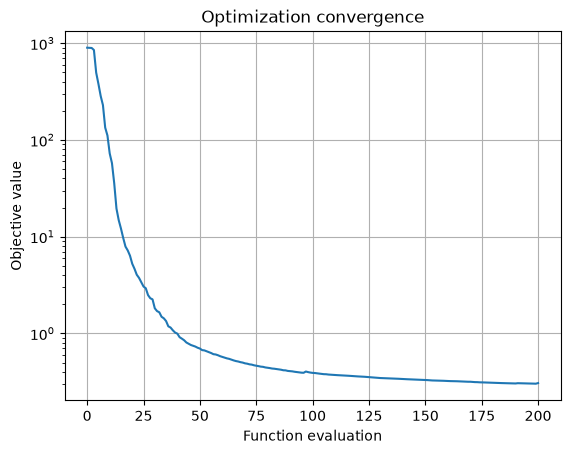

In [6]:
# Plot convergence
plt.figure()
plt.semilogy(opt_info["obj_history"])
plt.xlabel("Function evaluation")
plt.ylabel("Objective value")
plt.title("Optimization convergence")
plt.grid(True)
plt.show()

In [7]:
print(f"Iterations:           {opt_info['num_iter']}")
print(f"Objective evaluations: {len(opt_info['obj_history'])}")
print(f"Result info:          {opt_info['result_info']}")

Iterations:           200
Objective evaluations: 201
Result info:          {'status': -1, 'objective': 0.3065690156072378, 'num_iter': 200}


Note that the number of objective evaluations is higher than the number of iterations,
because of solver-internal evaluations (e.g. line search).

``result_info`` holds the solver's own result details. Every solver reports its iteration
count there under ``num_iter``, which is what ``opt_info["num_iter"]`` is taken from.

## Solver-specific configuration via the `solver` dict

Pass a dict to `solver` instead of a string to configure solver-internal attributes.
`"name"` selects the solver

**SciPy (L-BFGS-B):**
```python
pln.prop_opt = {
    "solver": {
        "name": "scipy",
        "abs_obj_tol": 1e-8,        # convergence tolerance (default 1e-5)
        "method": "L-BFGS-B",       # any method scipy.optimize.minimize accepts
        "options": {
            "ftol": 1e-8,           # method-specific options, incl. individual tolerances
            "gtol": 1e-10,
            "maxcor": 20,
        },
    },
}
```

`abs_obj_tol` sets whichever tolerance the chosen method understands (`ftol`, `gtol`,
`xtol`, ...). Set one of those in `options` as well and that value wins for that tolerance,
which is how SciPy itself resolves it — useful when a method's tolerances need tuning
individually. The iteration cap is the exception: it always comes from `max_iter`, under
whichever name the method uses (`maxiter`, or `maxfun` for TNC).

**IPOPT:**
```python
pln.prop_opt = {
    "solver": {
        "name": "ipopt",
        "options": {
            "tol": 1e-12,                       # overall convergence tolerance (default 1e-10)
            "acceptable_obj_change_tol": 1e-6,  # acceptable objective change (default 1e-4)
            "dual_inf_tol": 1e-6,               # dual infeasibility tolerance (default 1e-4)
            "compl_inf_tol": 1e-6,              # complementarity tolerance (default 1e-4)
            "acceptable_iter": 10,              # iterations within acceptable tol (default 5)
        },
    },
}
```

`max_iter`, `max_cpu_time` and `acceptable_tol` are not IPOPT-dict options here: they come from
the generic solver attributes (`max_iter`, `max_time`, `abs_obj_tol`), so set those instead.

## Where IPOPT's output goes

IPOPT is a C library and prints its iteration table straight to the process' standard
output descriptor, which Jupyter does not display. `output_mode` controls the routing:

| Mode        | Behaviour                                                          |
|-------------|--------------------------------------------------------------------|
| `"auto"`    | Default. Native output in a terminal, captured into the log in a notebook |
| `"native"`  | Always leave the output on the descriptor                          |
| `"logging"` | Always capture it and emit it through Python's `logging`           |

Captured output is logged in full, including the convergence summary and the `EXIT:` line
that the iteration callback does not expose. `display=False` silences it either way.

```python
pln.prop_opt = {"solver": {"name": "ipopt", "output_mode": "logging"}}
```

The records go to the `pyRadPlan.optimization.solvers._ipopt` logger at `INFO` level, so
they only appear once logging is configured for it (as `logging.basicConfig` does above).